In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy import stats
import os

### Loading the data

In [2]:
df = pd.read_csv('../data/kenya.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


## **Data Loading & Date Parsing**

### Add a Country column with the Ethiopia value

In [3]:
df_clean = df.copy()

In [4]:
df_clean["Country"] = "kenya"
df_clean.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,kenya


### Convert the YEAR and DOY columns into a proper datetime column

In [5]:
df_clean["Date"] = pd.to_datetime(df_clean["YEAR"] * 1000 + df_clean["DOY"], format="%Y%j")
df_clean.drop(columns=["DOY"], inplace=True)
df_clean.sample(5)


,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
3273,2023,20.55,27.00,16.20,10.80,0.07,75.68,4.14,5.12,83.58,13.23,kenya,2023-12-18
790,2017,21.46,29.07,14.39,14.68,0.67,59.13,4.37,6.44,83.65,10.55,kenya,2017-03-01
2512,2021,21.33,29.58,14.64,14.94,0.09,59.90,3.72,4.97,83.58,10.44,kenya,2021-11-17
3839,2025,19.55,27.24,13.96,13.28,0.80,68.80,2.15,3.32,83.83,10.98,kenya,2025-07-06
2752,2022,19.29,27.12,13.49,13.63,0.66,68.17,3.28,4.22,83.77,10.63,kenya,2022-07-15


### Extract Month as a separate colum

In [6]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean.sample(5)

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
3326,2024,21.83,29.43,15.65,13.78,0.01,65.74,3.53,4.65,83.76,12.12,kenya,2024-02-09,2
388,2016,20.65,28.22,14.35,13.87,0.03,63.85,2.41,3.96,83.83,10.84,kenya,2016-01-24,1
2818,2022,20.56,29.91,13.71,16.20,0.16,64.37,3.42,5.30,83.79,10.50,kenya,2022-09-19,9
1257,2018,17.40,25.63,10.61,15.02,0.00,70.73,1.94,3.74,83.99,10.07,kenya,2018-06-11,6
3064,2023,20.85,28.30,15.78,12.52,1.47,73.16,2.41,3.35,83.80,12.68,kenya,2023-05-23,5


## **Summary Statistics & Missing-Value Report**

#### Replace all occurrences of -999 with np.nan

In [7]:
df_clean.replace(-999, np.nan, inplace=True)
df_clean.sample(5)

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
2270,2021,21.44,29.09,16.26,12.83,3.05,66.84,4.55,5.75,83.48,11.93,kenya,2021-03-20,3
1495,2019,23.22,31.62,16.10,15.52,0.03,46.72,4.10,5.62,83.61,9.37,kenya,2019-02-04,2
3945,2025,21.86,31.04,13.11,17.93,0.00,49.76,2.75,5.03,83.62,8.57,kenya,2025-10-20,10
1302,2018,17.55,25.04,12.02,13.02,0.18,69.23,2.54,3.99,83.95,9.75,kenya,2018-07-26,7
88,2015,21.46,28.26,15.98,12.28,0.78,67.81,2.93,3.97,83.60,12.30,kenya,2015-03-30,3


In [8]:
df_clean.isna().sum()

YEAR           0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Handle duplicate rows

In [9]:
# drop any duplicate rows
df_clean.duplicated().sum()


0

In [10]:
df_clean.describe()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## **Outlier Detection & Basic Cleaning**

### Detect outliers using z-score

In [11]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df_clean[cols_to_check]))

In [12]:
outliers_mask=(z_scores>3).any(axis=1)
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 121


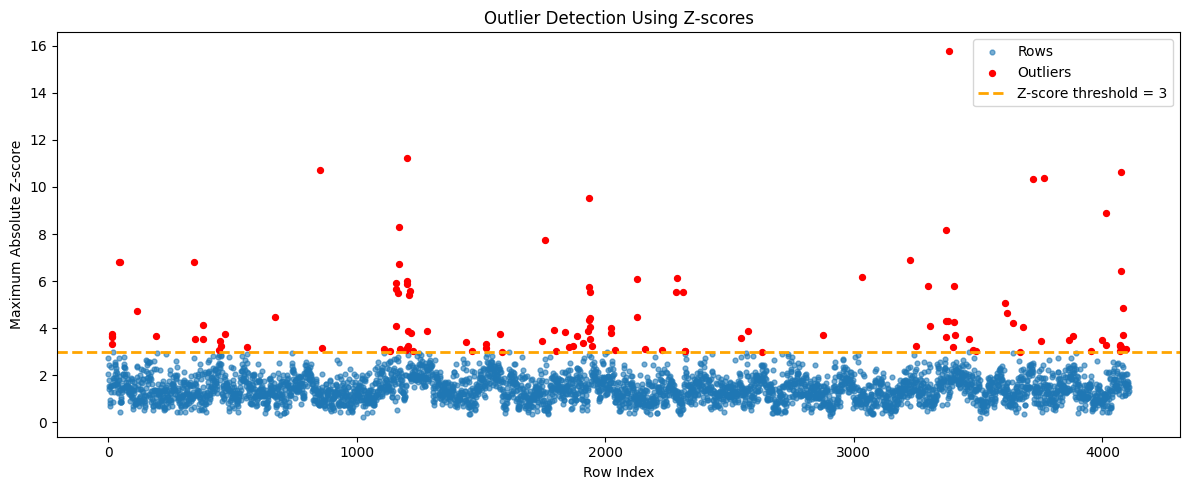

In [13]:
max_z = np.abs(z_scores).max(axis=1)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean.index, max_z, s=12, alpha=0.6, label="Rows")
plt.scatter(df_clean.index[outliers_mask], max_z[outliers_mask], color="red", s=18, label="Outliers")
plt.axhline(3, color="orange", linestyle="--", linewidth=2, label="Z-score threshold = 3")
plt.title("Outlier Detection Using Z-scores")
plt.xlabel("Row Index")
plt.ylabel("Maximum Absolute Z-score")
plt.legend()
plt.tight_layout()
plt.show()

### 🧹 Outlier Handling Strategy

Outliers were identified using Z-scores, with a threshold of (|Z| > 3). Rather than removing all outliers indiscriminately, a domain-aware approach was applied to distinguish between data errors, noise, and meaningful extreme weather events.

#### 1. Dropping Invalid Observations

Rows were **dropped** only when they violated known physical or logical constraints:

* ( T2M_MAX < T2M_MIN )
* ( T2M_RANGE \neq T2M_MAX - T2M_MIN )
* Relative humidity ((RH2M)) outside the range ([0, 100])
* Negative wind speed values

These represent data inconsistencies or measurement errors rather than true outliers.
In our case no such data was found. 

---

#### 2. Retaining Multi-variable Outliers

Rows where **two or more variables simultaneously exceeded the Z-score threshold** were **retained**. These accounted for approximately **1% of the dataset (6 rows)**.

These observations are likely to represent **real meteorological events**, such as:

* Storms (e.g., high wind speed and high precipitation)
* Temperature anomalies (e.g., unusually hot or cold days)

For example, **13 rows were identified as storm event and one as heat event**, characterized by concurrent high values in `WS2M_MAX` and `PRECTOTCORR`. Such patterns are physically meaningful and should be preserved.
we have also seen all outliers might be rearly extreme values so the data outliers were all retained.

---

#### 3. Capping Single-variable Outliers

Rows where **only one variable exceeded the Z-score threshold** were treated as potential noise or measurement spikes. Instead of removing these rows, the extreme values were **capped** using percentile-based clipping (1st and 99th percentiles).

This approach:

* Reduces the impact of extreme values on analysis and modeling
* Preserves the overall structure and continuity of the dataset

In the data there were no single variable outliers

---

#### **Final Strategy Summary**

| Category                               | Action     | Rationale          |
| -------------------------------------- | ---------- | ------------------ |
| Physically inconsistent values         | **Drop**   | Data errors        |
| Multi-variable outliers (≥2 variables) | **Retain** | Likely real events |
| Single-variable outliers               | **Cap**    | Likely noise       |

---

This approach ensures that important extreme weather patterns are preserved while minimizing the influence of erroneous or noisy data points.


In [14]:
outlier_counts = pd.Series((z_scores > 3).sum(axis=0), index=cols_to_check)
total_rows_per_col = df_clean[cols_to_check].notna().sum(axis=0)

outlier_counts = pd.DataFrame({
    "Outlier_Count": outlier_counts,
    "Outlier_Percentage (%)": (outlier_counts / total_rows_per_col) * 100
})

print(outlier_counts)

             Outlier_Count  Outlier_Percentage (%)
T2M                      8                0.194742
T2M_MAX                  3                0.073028
T2M_MIN                  9                0.219085
PRECTOTCORR             92                2.239533
RH2M                     6                0.146056
WS2M                     0                0.000000
WS2M_MAX                 6                0.146056


### Detecting Invalid Observations

In [15]:
# Data quality checks
humidity_col = "RH2M" if "RH2M" in df_clean.columns else "Humidity"
wind_col = "WS2M" if "WS2M" in df_clean.columns else "Wind speed"

checks = pd.DataFrame(index=df_clean.index)

# 1) T2M_MAX < T2M_MIN
checks["T2M_MAX_lt_T2M_MIN"] = df_clean["T2M_MAX"] < df_clean["T2M_MIN"]

# 2) T2M_RANGE != T2M_MAX - T2M_MIN
expected_range = df_clean["T2M_MAX"] - df_clean["T2M_MIN"]
checks["T2M_RANGE_mismatch"] = ~np.isclose(df_clean["T2M_RANGE"], expected_range, equal_nan=True)

# 3) Humidity < 0 or > 100
checks["Humidity_out_of_bounds"] = (df_clean[humidity_col] < 0) | (df_clean[humidity_col] > 100)

# 4) Wind speed < 0
checks["Wind_speed_negative"] = df_clean[wind_col] < 0

# Combine and report
checks["any_issue"] = checks.any(axis=1)

print("Issue counts by rule:")
print(checks.drop(columns="any_issue").sum())

print(f"\nTotal rows with at least one issue: {checks['any_issue'].sum()}")

# Show problematic rows with relevant columns
problem_rows = df_clean.loc[
    checks["any_issue"],
    [c for c in ["Date", "T2M_MIN", "T2M_MAX", "T2M_RANGE", humidity_col, wind_col] if c in df_clean.columns]
].copy()

problem_rows["T2M_MAX_lt_T2M_MIN"] = checks.loc[checks["any_issue"], "T2M_MAX_lt_T2M_MIN"].values
problem_rows["T2M_RANGE_mismatch"] = checks.loc[checks["any_issue"], "T2M_RANGE_mismatch"].values
problem_rows["Humidity_out_of_bounds"] = checks.loc[checks["any_issue"], "Humidity_out_of_bounds"].values
problem_rows["Wind_speed_negative"] = checks.loc[checks["any_issue"], "Wind_speed_negative"].values

if not problem_rows.empty:
    print(problem_rows.head(10))

Issue counts by rule:
T2M_MAX_lt_T2M_MIN        0
T2M_RANGE_mismatch        0
Humidity_out_of_bounds    0
Wind_speed_negative       0
dtype: int64

Total rows with at least one issue: 0


In [16]:
df_temp = df_clean.copy()

In [17]:
df_temp["is_outlier"] = outliers_mask
df_temp["outlier_count"] = df_temp[cols_to_check].apply(lambda row: (row > 3).sum(), axis=1)

### Detect Multi-variable Outliers

In [18]:
T2M_idx = cols_to_check.index("T2M")
T2M_MAX_idx = cols_to_check.index("T2M_MAX")
T2M_MIN_idx = cols_to_check.index("T2M_MIN")
WS2M_MAX_idx = cols_to_check.index("WS2M_MAX")
PRECTOTCORR_idx = cols_to_check.index("PRECTOTCORR")
RH2M_idx = cols_to_check.index("RH2M")

df_temp["heatwave_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, T2M_idx] > 2) &
    (z_scores[:, T2M_MAX_idx] > 2) &
    (z_scores[:, T2M_MIN_idx] > 2)
)

df_temp["storm_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, WS2M_MAX_idx] > 2) &
    (z_scores[:, PRECTOTCORR_idx] > 2) &
    (df_temp["RH2M"] > 70)
)

In [19]:
heatwaves = df_temp["heatwave_flag"].sum()
storms = df_temp["storm_flag"].sum()
print("Number of heatwave days:", heatwaves)
print("Number of Storm days:", storms)

Number of heatwave days: 1
Number of Storm days: 13


In [20]:
outlier_mask = df_temp["is_outlier"]
outlier_df = df_temp.loc[outlier_mask]

# Run consistency checks only on outlier rows
temp_consistency = (
    (outlier_df["T2M_MIN"] <= outlier_df["T2M"]) &
    (outlier_df["T2M"] <= outlier_df["T2M_MAX"]) &
    (np.abs(outlier_df["T2M_RANGE"] - (outlier_df["T2M_MAX"] - outlier_df["T2M_MIN"])) < 1e-3)
)

wind_consistency = outlier_df["WS2M"] <= outlier_df["WS2M_MAX"]
humidity_consistency = (outlier_df["RH2M"] >= 0) & (outlier_df["RH2M"] <= 100)

p95_rain = outlier_df["PRECTOTCORR"].quantile(0.95)
storm_consistency = ~(
    (outlier_df["PRECTOTCORR"] > p95_rain) &
    (outlier_df["RH2M"] < 30)  # suspicious: heavy rain but very dry air
)

relationship_valid_outliers = (
    temp_consistency &
    wind_consistency &
    humidity_consistency &
    storm_consistency
)

# Map back to full index (non-outliers set to False)
relationship_valid = pd.Series(False, index=df_temp.index)
relationship_valid.loc[outlier_df.index] = relationship_valid_outliers

# Keep multi-variable logic within outliers only
multi_mask = outlier_mask & (df_temp["outlier_count"] >= 2)

valid_multi = multi_mask & relationship_valid
invalid_multi = multi_mask & ~relationship_valid

print("Outlier rows checked:", outlier_mask.sum())
print("Valid multi-variable outliers:", valid_multi.sum())
print("Invalid multi-variable outliers:", invalid_multi.sum())

Outlier rows checked: 121
Valid multi-variable outliers: 121
Invalid multi-variable outliers: 0


## Handle remaining missing values

In [21]:
# check missing values
df_clean.isna().sum()

YEAR           0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

## Export the cleaned DataFrame

In [22]:
df_clean.head()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,kenya,2015-01-01,1
1,2015,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,kenya,2015-01-02,1
2,2015,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,kenya,2015-01-03,1
3,2015,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,kenya,2015-01-04,1
4,2015,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,kenya,2015-01-05,1


In [23]:
os.makedirs("data", exist_ok=True)

country = "kenya"
output_path = f"data/{country}_clean.csv"

print("Saving to:", os.path.abspath(output_path))

df_clean.to_csv(output_path, index=False)

print("Exists after save:", os.path.exists(output_path))
df_temp = pd.read_csv('data/kenya_clean.csv')
df_temp.head()


Saving to: /home/melki/Desktop/tenx/climate-challenge-week0/notebooks/data/kenya_clean.csv
Exists after save: True


,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,kenya,2015-01-01,1
1,2015,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,kenya,2015-01-02,1
2,2015,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,kenya,2015-01-03,1
3,2015,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,kenya,2015-01-04,1
4,2015,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,kenya,2015-01-05,1


# **Time Series Analysis**

In [24]:
df_clean["Month"].value_counts()

Month
1     372
3     372
5     341
7     341
8     341
10    341
12    341
2     339
4     330
6     330
9     330
11    330
Name: count, dtype: int64

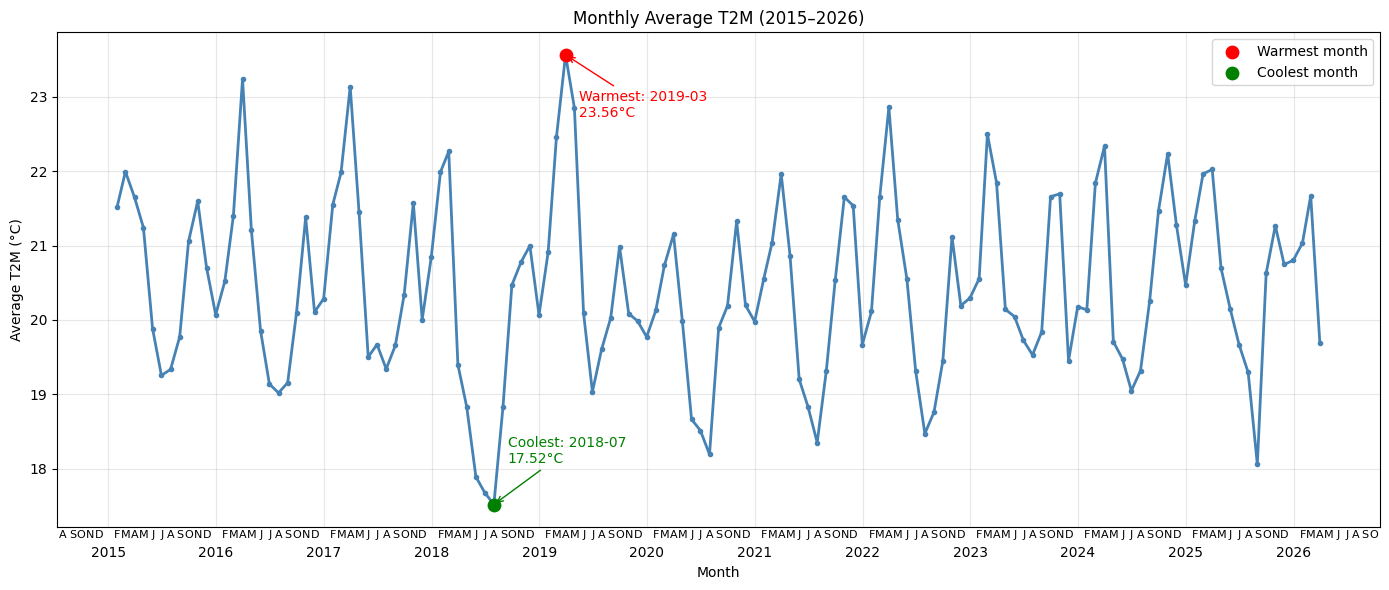

In [25]:
monthly_avg_t2m = df_clean.set_index("Date")["T2M"].resample("ME").mean()

warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_avg_t2m.index,
    monthly_avg_t2m.values,
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=3
)

plt.scatter([warmest_month], [monthly_avg_t2m[warmest_month]], color="red", s=80, zorder=5, label="Warmest month")
plt.scatter([coolest_month], [monthly_avg_t2m[coolest_month]], color="green", s=80, zorder=5, label="Coolest month")

plt.annotate(
    f"Warmest: {warmest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[warmest_month]:.2f}°C",
    xy=(warmest_month, monthly_avg_t2m[warmest_month]),
    xytext=(10, -45),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.annotate(
    f"Coolest: {coolest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[coolest_month]:.2f}°C",
    xy=(coolest_month, monthly_avg_t2m[coolest_month]),
    xytext=(10, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green"
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0]))

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

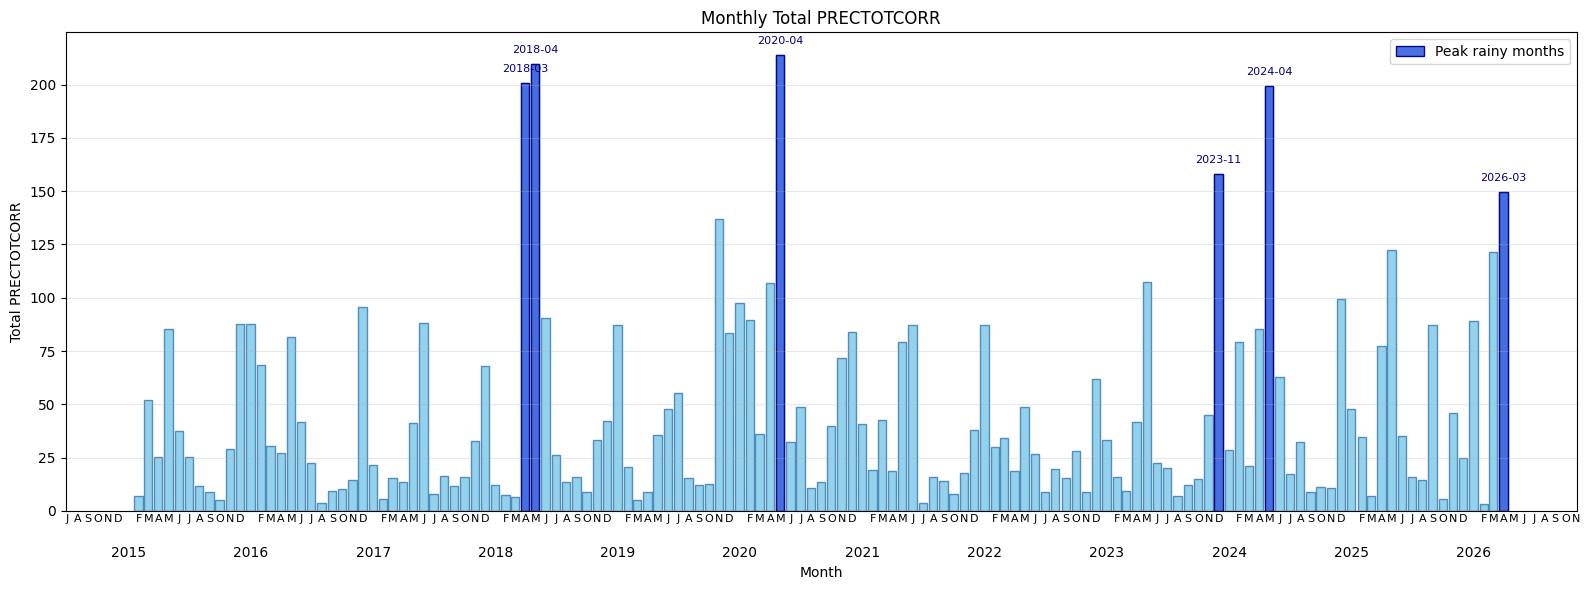

Peak rainy-season months (highest monthly totals):
Date
2018-03-31    200.73
2018-04-30    209.74
2020-04-30    213.89
2023-11-30    158.06
2024-04-30    199.42
2026-03-31    149.45
Name: PRECTOTCORR, dtype: float64


In [26]:
# Monthly total precipitation (PRECTOTCORR)
monthly_total_prectotcorr = df_clean.set_index("Date")["PRECTOTCORR"].resample("ME").sum()

# Pick peak rainy-season months (top 6 wettest months in the full time series)
peak_months = monthly_total_prectotcorr.nlargest(6).sort_index()

plt.figure(figsize=(16, 6))
plt.bar(
    monthly_total_prectotcorr.index,
    monthly_total_prectotcorr.values,
    width=25,
    color="skyblue",
    edgecolor="steelblue",
    alpha=0.9
)

# Highlight and annotate peak months
plt.bar(
    peak_months.index,
    peak_months.values,
    width=25,
    color="royalblue",
    edgecolor="navy",
    alpha=0.95,
    label="Peak rainy months"
)


for dt, val in peak_months.items():
    plt.annotate(
        dt.strftime("%Y-%m"),
        xy=(dt, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="navy"
    )

ax = plt.gca()

# Year label every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("\n%Y"))

# Month labels as first letter (J, F, M, ...)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(
    FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0])
)

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Total PRECTOTCORR")
plt.xlabel("Month")
plt.ylabel("Total PRECTOTCORR")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Peak rainy-season months (highest monthly totals):")
print(peak_months)

**Climate Trends and Anomalies: Kenya (2015–2026)**

### Precipitation (Monthly Total PRECTOTCORR)
- **Clear seasonal pattern**: The region shows a bimodal rainfall distribution. While there is regular seasonal rain, the "Peak rainy months" (highlighted in dark blue) identify specific extreme precipitation events that deviate significantly from the monthly average.
- **Key anomalies**:
  - The highest recorded rainfall occurred in **May 2020 (213.89 mm)**.
  - A massive back-to-back rainfall event occurred in early 2018, with **Aprile 2018 (200.73 mm)** and **Aprile 2018 (209.74 mm)** representing a very wet season.
  - Recent years show significant spikes in **May 2024 (199.42 mm)** and **March 2026 (149.45 mm)**.
  - An unusual late-season anomaly is noted in **December 2023 (158.06 mm)**, which is typically a much drier month.
- **Trend**: There is high inter-annual variability. The years 2018, 2020, and 2024 stand out as exceptionally wet years compared to the relatively drier intervals in 2017 and 2021-2022.

### Temperature (Monthly Average T2M)
- **Clear seasonal cycle**: Temperatures follow a consistent annual rhythm, peaking in the spring (**March–May**) and reaching their annual minimum during the mid-year rainy period (**July–August**).
- **Key anomalies**:
  - **Warmest month**: Aprile 2019 at **23.56°C**.
  - **Coolest month**: August 2018 at **17.52°C**.
- **Trend**: The temperature remains relatively stable across the 11-year period without a distinct long-term warming or cooling slope. However, 2018–2019 shows the highest volatility, containing both the record low and record high within an 8-month span.

### Relationship Between Precipitation and Temperature
- **Inverse seasonal relationship**: There is a strong correlation between peak rainfall and temperature suppression. The **coolest month (July 2018)** immediately followed the record-breaking rainfall of Spring 2018, suggesting that high soil moisture and cloud cover significantly lowered surface temperatures.
- **Notable co-occurrences**:
  - The **warmest month (Aprile 2019)** occurred exactly one year after the extreme 200mm+ rainfall of March 2018; in 2019, the lack of such an extreme rainfall peak in Aprile allowed temperatures to reach record highs.
  - Most "Peak rainy months" (May 2018, 2020, 2024) occur during the temperature descent, confirming that heavy precipitation events act as a cooling mechanism for the region.
- **Implication**: Rainfall intensity is the primary driver of temperature anomalies in this data. Extreme wet months lead to significant cooling, while the absence of expected rains during the "warm" season (April/May) leads to record-breaking heat.

# **Correlation & Relationship Analysis**

### Heatmap of correlations across all numeric columns

In [27]:
# which columns are numberic
df_clean.select_dtypes(include=[np.number]).columns.tolist()

['YEAR',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'PRECTOTCORR',
 'RH2M',
 'WS2M',
 'WS2M_MAX',
 'PS',
 'QV2M',
 'Month']

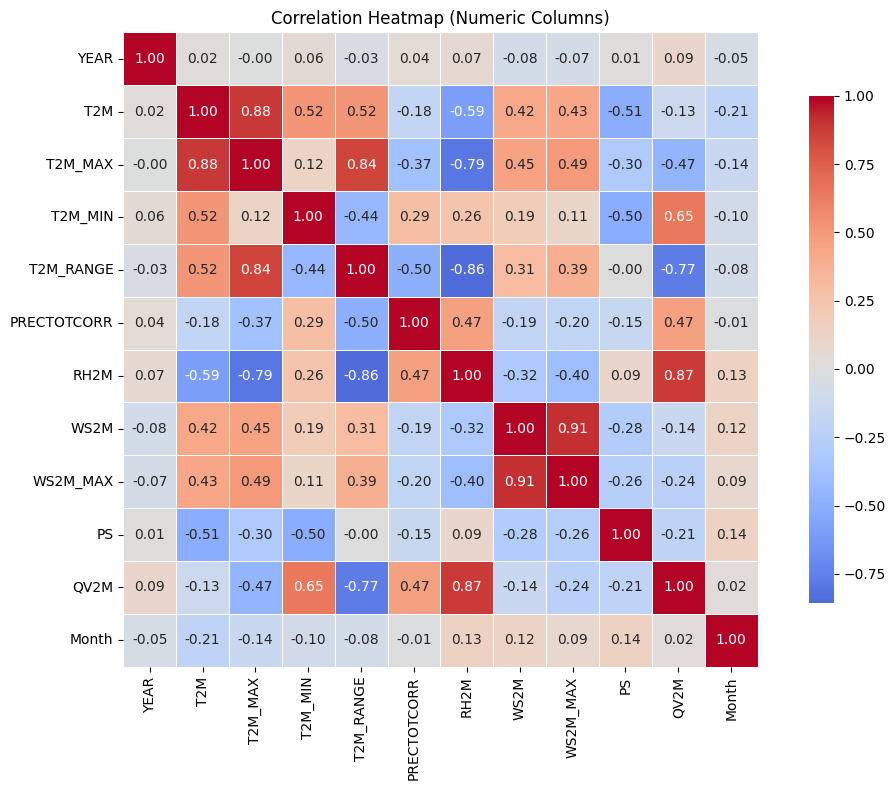

In [28]:
# Correlation heatmap across all numeric columns in df_clean
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

## Scatter plots

### T2M vs. RH2M and T2M_RANGE vs. WS2M

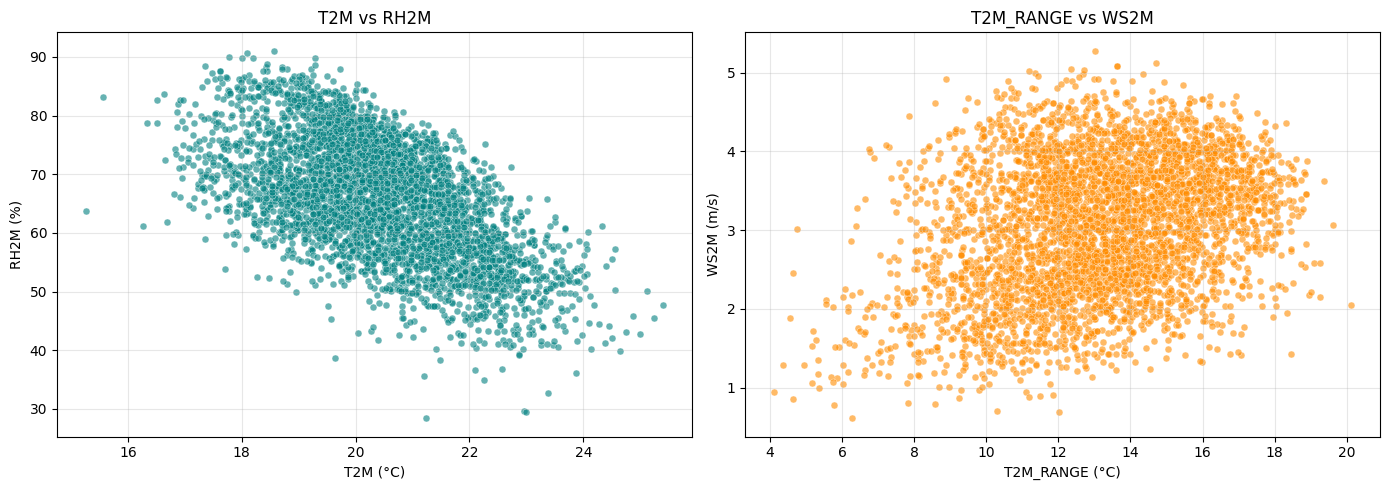

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clean, x="T2M", y="RH2M",
    alpha=0.6, s=25, ax=axes[0], color="teal"
)
axes[0].set_title("T2M vs RH2M")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].grid(alpha=0.3)

sns.scatterplot(
    data=df_clean, x="T2M_RANGE", y="WS2M",
    alpha=0.6, s=25, ax=axes[1], color="darkorange"
)
axes[1].set_title("T2M_RANGE vs WS2M")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Three Strongest Correlations

#### 1. Positive Correlation between T2M_RANGE and WS2M (Right Plot)
*   **Identification:** There is a clear, moderately strong positive linear relationship between the 2-meter temperature range (T2M_RANGE) and the 2-meter wind speed (WS2M). As the temperature range increases, the wind speed generally increases.
*   **Interpretation:** This suggests that days with a high degree of diurnal temperature variation (large difference between maximum and minimum temperature) are often associated with higher wind speeds. This could be due to increased atmospheric instability and convective mixing during days with significant solar heating.

#### 2. Strong Negative Correlation between T2M and RH2M for Temperatures > 15°C (Left Plot, Right Side)
*   **Identification:** In the "T2M vs RH2M" plot, there is a very strong negative correlation for data points where the temperature exceeds approximately 15°C. The upper boundary and general cloud of data points slope downward sharply.
*   **Interpretation:** This represents the physical relationship where, assuming constant moisture content, increasing the air temperature decreases its relative humidity because warmer air has a higher capacity to hold water vapor. This trend is dominant during warmer periods.

#### 3. Moderate Positive Correlation between T2M and RH2M for Temperatures < 14°C (Left Plot, Left Side)
*   **Identification:** For temperatures below roughly 14°C, the "T2M vs RH2M" plot shows a visible positive trend. As the temperature increases from 10°C to 14°C, the relative humidity values also tend to rise toward a peak.
*   **Interpretation:** At lower temperatures, warmer conditions in this specific dataset appear to coincide with higher moisture levels. This might reflect specific regional weather patterns, such as humid air masses being associated with slightly higher temperatures during cool seasons or nighttime periods.

# **Distribution Analysis**

In [30]:
df_clean.head()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,kenya,2015-01-01,1
1,2015,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,kenya,2015-01-02,1
2,2015,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,kenya,2015-01-03,1
3,2015,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,kenya,2015-01-04,1
4,2015,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,kenya,2015-01-05,1


### **Histogram of PRECTOTCORR**

#### Check if the histogram of PRECTOTCORR

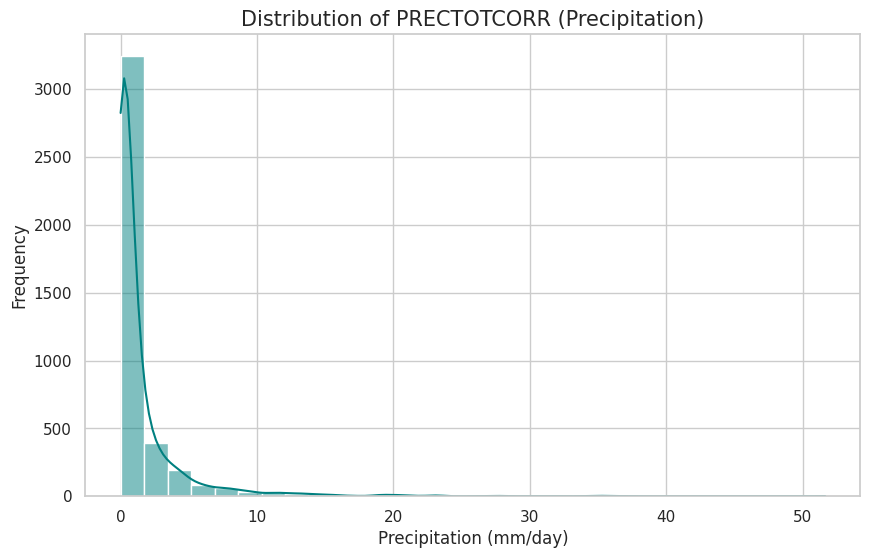

In [31]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], kde=True, color='teal', bins=30)

plt.title('Distribution of PRECTOTCORR (Precipitation)', fontsize=15)
plt.xlabel('Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Because the distribution of PRECTOTCORR is heavily skewed we apply log scale to the X-axis to better visualize the distribution.

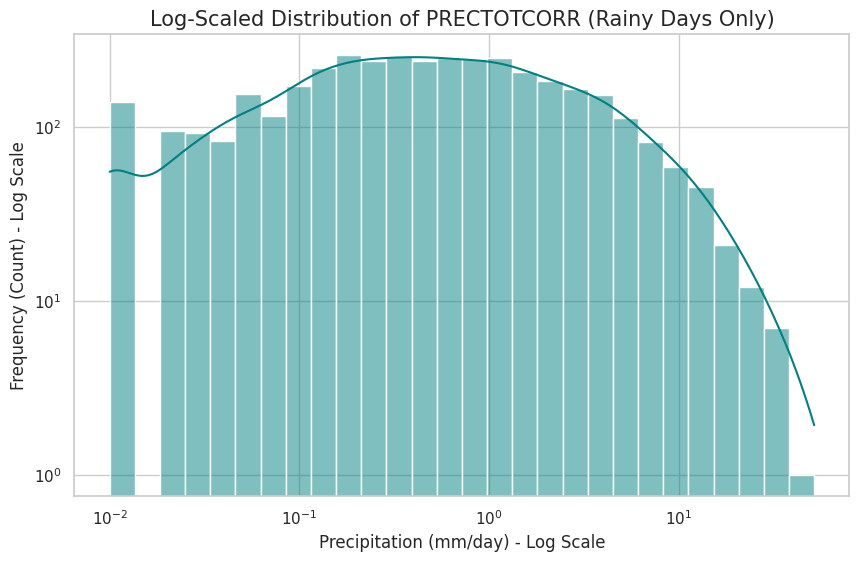

In [32]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6)) 

# Filtering for values > 0 is necessary for log scales because log(0) is undefined
rainy_days = df[df['PRECTOTCORR'] > 0]['PRECTOTCORR']

# log_scale=True automatically calculates log-spaced bins for the X-axis
sns.histplot(rainy_days, kde=True, color='teal', log_scale=True)

# Also applying log scale to the Y-axis (Frequency) to see rare extreme events better
plt.yscale('log')

plt.title('Log-Scaled Distribution of PRECTOTCORR (Rainy Days Only)', fontsize=15)
plt.xlabel('Precipitation (mm/day) - Log Scale', fontsize=12)
plt.ylabel('Frequency (Count) - Log Scale', fontsize=12)

plt.show()

### **Bubble chart**

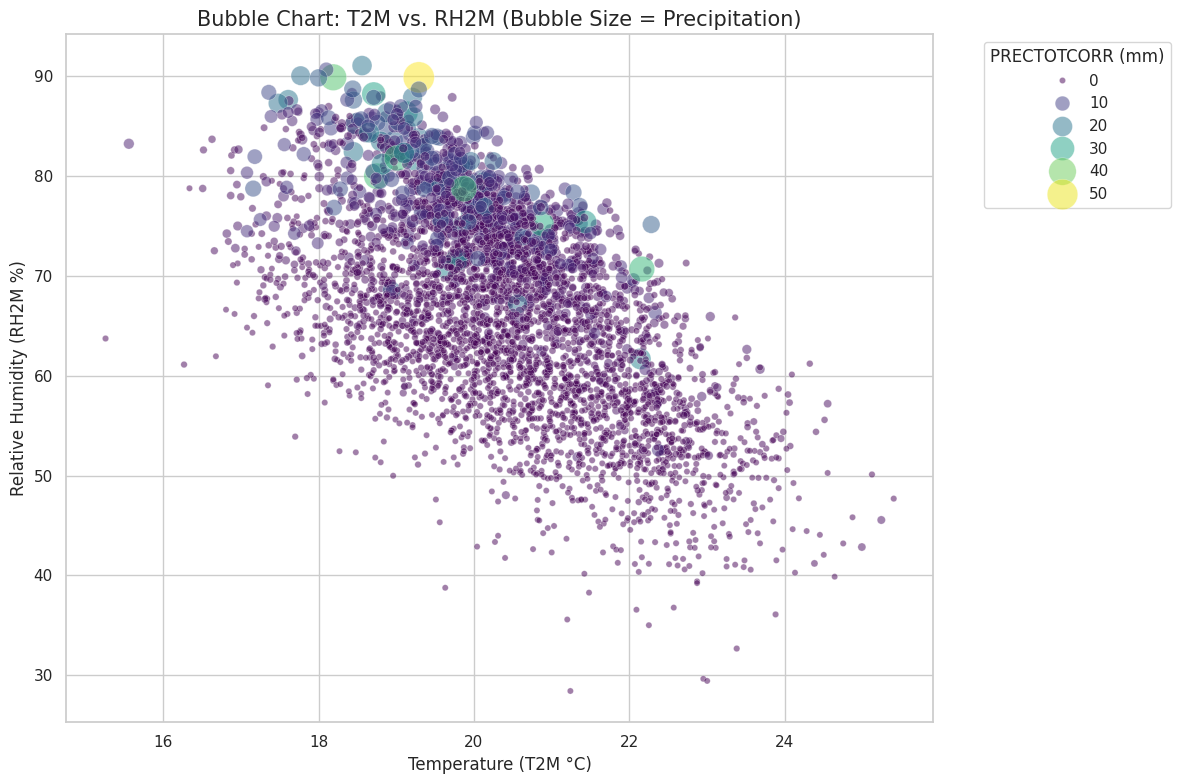

In [33]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# Create the bubble chart
# s=df['PRECTOTCORR'] * 20: Scale factor to make bubbles visible
# alpha=0.5: Transparency to see overlapping bubbles
# hue='PRECTOTCORR': Colors bubbles by precipitation intensity for better clarity
bubble_plot = sns.scatterplot(
    data=df, 
    x='T2M', 
    y='RH2M', 
    size='PRECTOTCORR', 
    hue='PRECTOTCORR',
    sizes=(20, 500),      
    alpha=0.5,           
    palette='viridis'     
)

# Customizing the chart
plt.title('Bubble Chart: T2M vs. RH2M (Bubble Size = Precipitation)', fontsize=15)
plt.xlabel('Temperature (T2M °C)', fontsize=12)
plt.ylabel('Relative Humidity (RH2M %)', fontsize=12)

# Move the legend outside to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='PRECTOTCORR (mm)')

plt.tight_layout()
plt.show()

### Interpretation of Bubble Chart: T2M vs. RH2M (Precipitation)

This bubble chart adds a third dimension **Precipitation (PRECTOTCORR)** to the relationship between temperature and relative humidity. Here is an analysis of the key patterns observed:

#### 1. The "Rainy Sweet Spot"
*   **Observation:** The largest bubbles (representing high precipitation, 60mm to 90mm) are almost exclusively clustered at the top of the curve.
*   **Interpretation:** Significant rainfall occurs only when **Relative Humidity is high (above 80%)**. Even if temperatures are moderate, rain is highly unlikely if the humidity is low (below 70%). This confirms the physical requirement of near-saturated air for precipitation to form.

#### 2. Temperature Window for Peak Precipitation
*   **Observation:** The heaviest rainfall events (the largest, lightest-colored bubbles) are concentrated within a specific temperature range, roughly **13°C to 19°C**.
*   **Interpretation:** In this specific climate dataset, the most intense storms or rainy days don't happen during the coldest or hottest times. Instead, they occur in a "mid-range" temperature window where the air can hold sufficient moisture and conditions are optimal for condensation.

#### 3. Low Humidity = Dry Conditions
*   **Observation:** The vast majority of the chart area, especially below 70% RH, is populated by tiny purple dots.
*   **Interpretation:** This indicates that for a wide range of temperatures (10°C to 22°C), if the relative humidity is low, precipitation is consistently near zero. This highlights that humidity is a much stronger predictor of rain than temperature alone.

#### 4. The Influence of High Temperature on Rain
*   **Observation:** As temperatures climb toward the right side of the graph (above 18°C), the bubbles generally get smaller and the RH drops.
*   **Interpretation:** This follows the trend discussed earlier: warmer air has a higher capacity for moisture. Unless a significant amount of water vapor is added, the relative humidity drops, making it harder for the air to reach saturation and produce heavy rain.

### Summary
The chart demonstrates a **strong three-way dependency**: heavy precipitation requires a specific "Goldilocks" zone of moderate temperatures (13-19°C) combined with very high relative humidity (>60%). Outside of this zone, even if it is humid or warm, precipitation amounts remain minimal.